# PLOT A VARIABLE ACROSS RIGS

In [ ]:
from aind_vr_foraging_analysis.utils.parsing.parse import load_session_data
from pathlib import Path
import json
import os

main_path = Path(r"\\allen\aind\stage\vr-foraging\data")
mouse_n_to_explore = ("841310", "828425")  # tuple of mouse IDs
specified_dates = ("2026-04", "2026-05")  # specify the date to filter directories

def _read_json(path: str) -> dict:
    """Read a JSON file and return its contents as a dict."""
    try:
        with open(path) as f:
            return json.load(f)
    except FileNotFoundError as e:
        raise FileNotFoundError(f"Required file not found: {path}") from e
    except json.JSONDecodeError as e:
        raise ValueError(f"Invalid JSON format in file: {path}") from e


def load_streams_from_harp(data:dict, harp:str, list_of_stream_names:list[str], drop:list[str] = ["MessageType"]) -> dict[str, dict[str, str]]:
    """
    Collect a list of data streams from a specific harp device.

    Parameters
    ----------
    data : dict
        Dictionary of harp devices (e.g., data["harpX"]).
    stream_names : list[str]
        List of stream names to extract (e.g., ["WhoAmI", "HardwareVersionHigh"]).
    drop : List[str] | None (optional)
        List of columns to not collect

    Returns
    -------
    dict
        Nested dictionary: {harp_name: {stream_name: stream_values}}
    """
    stream_dict = {}
    for stream_name in list_of_stream_names:
        data[harp].streams[stream_name].load_from_file()
        stream_dict[stream_name]= data[harp].streams[stream_name].data.drop(columns=drop, errors="ignore")
    return stream_dict

mouse_n_to_explore = ("841310", "828425")  # tuple of mouse IDs
specified_dates = ("2026-02", "2026-04")  # specify the date to filter directories

dirs = []

# Level 1
dirs.extend([p for p in main_path.iterdir() if p.is_dir()])
filtered1_dirs = [
    d for d in dirs
    if any(mouse_id in os.path.basename(d) for mouse_id in mouse_n_to_explore)
]

print(str(dirs))

# Level 2
filtered1_dirs.extend([
    p2
    for p1 in main_path.iterdir() if p1.is_dir()
    for p2 in p1.iterdir() if p2.is_dir()
])

print(str(filtered1_dirs))

# Keep only directories containing one of the mouse IDs and one of the specified dates
filtered2_dirs = [
    d for d in filtered1_dirs
    if any(date in os.path.basename(d) for date in specified_dates)
]

print(str(filtered2_dirs))

results = {}

for path in filtered2_dirs:
   
    try:
        data = load_session_data(path)
        envmt_stream = load_streams_from_harp(data, "harp_environment_sensor", ["SensorData"]) 
        
        # Environment data
        envmt_cols = ["Pressure", "Temperature", "Humidity"]
        results[str(path)] = envmt_stream["SensorData"].loc[:, envmt_cols].agg(['max', 'min', 'mean', 'std']).to_dict() 

        # Session data
        rig_data = _read_json(Path(os.path.join(path, "behavior" ,"Logs", "rig_input.json")))
        session_data = _read_json(Path(os.path.join(path, "behavior" ,"Logs", "session_input.json")))
        results[str(path)]["rig"] = rig_data["rig_name"]
        results[str(path)]["date"] = session_data["date"]
        results[str(path)]["subject"] = session_data["subject"]

        
        
    except Exception as e:
        print(f"Not possible to read data in {path} > {e}")

print(results)


[WindowsPath('C:/Data/tests/828425_2026-02-04T220350Z'), WindowsPath('C:/Data/tests/828425_2026-02-05T202750Z'), WindowsPath('C:/Data/tests/828425_2026-02-06T203423Z'), WindowsPath('C:/Data/tests/828425_2026-02-09T203950Z'), WindowsPath('C:/Data/tests/828425_2026-02-10T210928Z'), WindowsPath('C:/Data/tests/828425_2026-02-11T203733Z'), WindowsPath('C:/Data/tests/828425_2026-02-13T190032Z'), WindowsPath('C:/Data/tests/828425_2026-02-17T212017Z'), WindowsPath('C:/Data/tests/828425_2026-02-19T210756Z'), WindowsPath('C:/Data/tests/841310_2026-02-16T213935Z'), WindowsPath('C:/Data/tests/841310_2026-02-17T212954Z'), WindowsPath('C:/Data/tests/841310_2026-02-18T211122Z'), WindowsPath('C:/Data/tests/841310_2026-02-19T210400Z')]
{'C:\\Data\\tests\\828425_2026-02-04T220350Z': {'Pressure': {'max': 102403.0, 'min': 102347.0, 'mean': 102368.8125, 'std': 14.022427558898926}, 'Temperature': {'max': 27.723661422729492, 'min': 25.1767520904541, 'mean': 26.932546615600586, 'std': 0.5996276140213013}, 'Hu

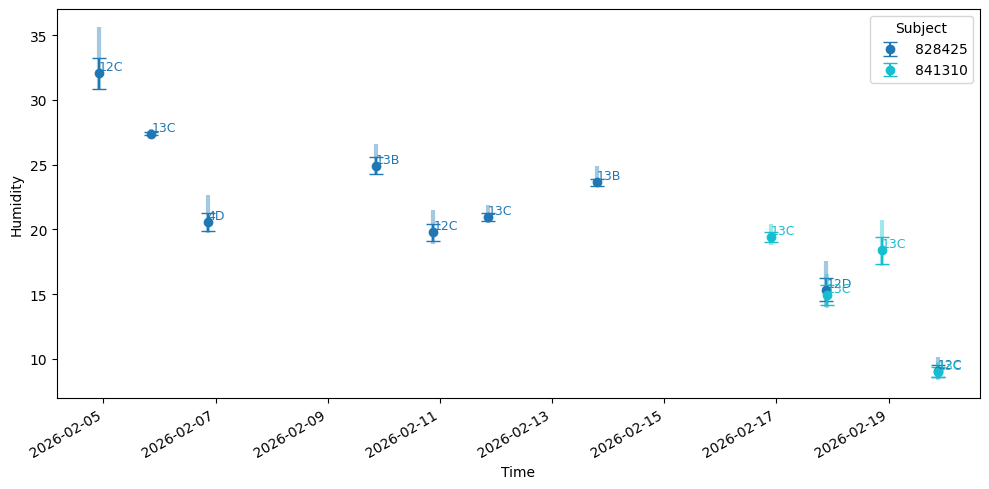

In [15]:
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np

# Only if `results` dictionary already exists

fig, ax = plt.subplots(figsize=(10, 5))

# Assign one color per subject automatically
subjects = list(set(v["subject"] for v in results.values()))
colors = plt.cm.tab10(np.linspace(0, 1, len(subjects)))
subject_colors = dict(zip(subjects, colors))

for path, data in results.items():

    # Parse time
    time = datetime.fromisoformat(data["date"].replace("Z", "+00:00"))

    # Humidity stats
    mean_h = data["Humidity"]["mean"]
    std_h = data["Humidity"]["std"]
    min_h = data["Humidity"]["min"]
    max_h = data["Humidity"]["max"]

    # Subject / rig
    subject = data["subject"]
    rig = data["rig"]

    color = subject_colors[subject]

    # Plot mean ± std
    ax.errorbar(
        time,
        mean_h,
        yerr=std_h,
        fmt='o',
        color=color,
        capsize=5,
        label=subject
    )

    # Plot min-max range as thinner line
    ax.vlines(
        time,
        min_h,
        max_h,
        color=color,
        alpha=0.4,
        linewidth=3
    )

    # Add rig label
    ax.text(
        time,
        mean_h,
        rig,
        fontsize=9,
        ha='left',
        va='bottom',
        color=color
    )

# Remove duplicate legend entries
handles, labels = ax.get_legend_handles_labels()
unique = dict(zip(labels, handles))
ax.legend(unique.values(), unique.keys(), title="Subject")

ax.set_xlabel("Time")
ax.set_ylabel("Humidity")
fig.autofmt_xdate()

plt.tight_layout()
plt.show()